In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Load the dataset

In [2]:
credit_risk=pd.read_csv('/content/cr_loan2.csv')
print(credit_risk.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


# Data cleaning and preprocessing

In [3]:
cr_age_rmvd = credit_risk[credit_risk['person_age'] <= 70]
person_emp_rmvd = cr_age_rmvd[cr_age_rmvd['person_emp_length'] <= 45]
clr_data = person_emp_rmvd.copy()
clr_data.fillna({'loan_int_rate': clr_data['loan_int_rate'].median()}, inplace=True)
cr_data_copy = clr_data.drop('loan_grade', axis=1)

# Categorical features treatment

---



In [4]:
cr_data_cat_treated = cr_data_copy.copy()
person_home_ownership = pd.get_dummies(cr_data_cat_treated['person_home_ownership'], drop_first=True).astype(int)
loan_intent = pd.get_dummies(cr_data_cat_treated['loan_intent'], drop_first=True).astype(int)
cr_data_cat_treated['cb_person_default_on_file_binary'] = np.where(cr_data_cat_treated['cb_person_default_on_file'] == 'Y', 1, 0)
data_scale = cr_data_cat_treated.drop(['person_home_ownership', 'loan_intent', 'loan_status', 'cb_person_default_on_file', 'cb_person_default_on_file_binary'], axis=1)

# Scaling numerical feature

In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_scale)
scaled_df = pd.DataFrame(scaled_data, columns=data_scale.columns)

# Combining scaled and categorical features

In [6]:
scaled_data_combined = pd.concat([scaled_df, person_home_ownership, loan_intent], axis=1)
scaled_data_combined['cb_person_default_on_file_binary'] = cr_data_cat_treated['cb_person_default_on_file_binary']
scaled_data_combined['loan_status'] = cr_data_cat_treated['loan_status']


# Drop rows with missing target values

In [7]:
scaled_data_combined = scaled_data_combined.dropna(subset=['loan_status'])

# Split features and target

In [8]:
features = scaled_data_combined.drop('loan_status', axis=1)
target = scaled_data_combined['loan_status']

# Drop rows where features have NaNs

In [9]:
features = features.dropna()
target = target.loc[features.index]

# Apply SMOTE

In [10]:
smote = SMOTE(random_state=42)
balanced_features, balance_target = smote.fit_resample(features, target)

# Resultant dataframe

In [11]:
resultant_df = pd.concat([balanced_features, balance_target], axis=1)
print(resultant_df.head())

   person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
0   -0.441211      -1.078051          -0.938456  -0.656810       0.597575   
1   -0.765899      -0.018803          -0.193790   4.000141       1.366226   
2   -0.603555      -0.229137           0.799097   4.000141       1.053554   
3   -1.090587      -1.072366          -0.690234  -1.130398      -1.268682   
4   -0.278867       0.201005           0.799097   4.000141       0.451010   

   loan_percent_income  cb_person_cred_hist_length  OTHER  OWN  RENT  \
0             3.767461                   -0.692664    0.0  1.0   0.0   
1             3.391072                   -0.939656    0.0  0.0   0.0   
2             3.579267                   -0.445671    0.0  0.0   1.0   
3             0.756347                   -0.939656    0.0  0.0   1.0   
4             2.638293                   -0.692664    0.0  1.0   0.0   

   EDUCATION  HOMEIMPROVEMENT  MEDICAL  PERSONAL  VENTURE  \
0        1.0              0.0      0.0     

In [12]:
print(resultant_df.shape)
resultant_df.head()

(48326, 17)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,OTHER,OWN,RENT,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE,cb_person_default_on_file_binary,loan_status
0,-0.441211,-1.078051,-0.938456,-0.656810,0.597575,3.767461,-0.692664,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.765899,-0.018803,-0.193790,4.000141,1.366226,3.391072,-0.939656,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,-0.603555,-0.229137,0.799097,4.000141,1.053554,3.579267,-0.445671,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.090587,-1.072366,-0.690234,-1.130398,-1.268682,0.756347,-0.939656,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
4,-0.278867,0.201005,0.799097,4.000141,0.451010,2.638293,-0.692664,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [13]:
clr_data.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

In [15]:
# Splitting data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(balanced_features, balance_target, test_size=0.20, random_state=42)

In [16]:
# Logistic Regression
logit = LogisticRegression()
logit.fit(x_train, y_train)

LogisticRegression()

In [17]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [18]:
# XGBoost
xgb = XGBClassifier()
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [19]:
# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(x_train, y_train)

GradientBoostingClassifier()

In [20]:
# Neural Network
nn = MLPClassifier()
nn.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier()

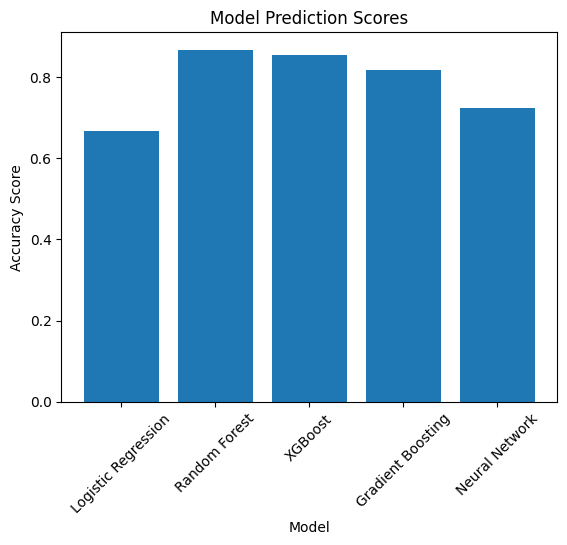

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = [logit, rf, xgb, gb, nn]
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting', 'Neural Network']
scores = []

for model in models:
    y_pred = model.predict(x_test)
    score = accuracy_score(y_test, y_pred)
    scores.append(score)

plt.bar(model_names, scores)
plt.title('Model Prediction Scores')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.xticks(rotation=45)
plt.show() # To see the output, run the code.

In [22]:
# Save using pickle
import joblib
# Save the Model
joblib.dump(rf, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [23]:
# Download the Model
from google.colab import files
files.download('rf_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import joblib
# Import the Model
model = joblib.load('rf_model.pkl')
scaler = joblib.load('scaler.pkl')

In [25]:
import numpy as np
import warnings

def simple_predict(model, scaler, input_array):
    # Separate the numerical and categorical inputs
    numerical_input = input_array[:7]  # The first 7 values should be numerical
    categorical_input = input_array[7:]  # The remaining values should be categorical

    # Scale the numerical input using the same scaler used during training
    scaled_numerical = scaler.transform([numerical_input])  # Reshape to 2D (1, 7)

    # Reshape categorical input to (1, 9) and combine it with the scaled numerical input
    categorical_input_reshaped = np.array(categorical_input).reshape(1, -1)

    final_input = np.hstack((scaled_numerical, categorical_input_reshaped))
    prediction = model.predict(final_input)[0]
    return "Loan Approved" if prediction == 1 else "Loan Rejected"

In [26]:
# Input Values: person_age, person_income, person_emp_length, loan_amnt, loan_int_rate, loan_percent_income, cb_person_cred_hist_length, OTHER, OWN, RENT, EDUCATION, HOMEIMPROVEMENT, MEDICAL, PERSONAL, VENTURE, cb_person_default_on_file_binary
input_data = [25, 60000, 5, 10000, 0.15, 0.25, 10, 0, 1, 0, 0, 0, 0, 0, 0, 0]  # shape (1, 16)

prediction = simple_predict(model, scaler, input_data)
print(prediction+"\n")

Loan Rejected



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
